## Problem Statement:
Predict if it will rain tomorrow (`RainTomorrow`) using today's weather in Australia (`weatherAUS.csv`).

This is a **Yes/No** problem (classification), not a dollar amount.
Only about 21% of days are rain days. A model that always says "No" would still be about 79% correct. So accuracy alone is not enough.


## Objectives
1. Find weather patterns that come before rain
2. Build models with **more than 75% accuracy**
3. Compare Logistic Regression, Random Forest, XGBoost, and a Neural Network
4. Check how well we catch rain days (not only accuracy)
5. Try GridSearch to tune a model, and SHAP to see which features matter


## Working Code


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score

from xgboost import XGBClassifier  #install using  pip install xgboost
import shap

# If needed, run: pip install seaborn xgboost shap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [3]:
# Load data
data_path = "weatherAUS.csv"
df = pd.read_csv(data_path, na_values=['NA'])

print("Dataset dimensions:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)

# Percent of missing values in each column
missing_pct = df.isnull().mean() * 100
print("\nMissing values (%):")
print(missing_pct.sort_values(ascending=False).round(1))

# Share of Yes / No / missing in the target
print("\nRainTomorrow class balance:")
print(df['RainTomorrow'].value_counts(dropna=False, normalize=True).round(3))

# RISK_MM is the next day's rainfall in mm. Using it would "cheat"
# because it already contains the answer to RainTomorrow.
df = df.drop(columns=['RISK_MM'])

# Remove rows where we do not know the answer (no target label)
df = df.dropna(subset=['RainTomorrow'])

# Convert the date string into year, month, day, and season
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Map month number to Australian season
season_map = {
    12: 'Summer', 1: 'Summer', 2: 'Summer',
    3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
    6: 'Winter', 7: 'Winter', 8: 'Winter',
    9: 'Spring', 10: 'Spring', 11: 'Spring'
}
df['Season'] = df['Month'].map(season_map)
df = df.drop(columns=['Date'])

print("\nAfter dropping unlabelled rows and converting dates:", df.shape)
display(df.head())


Dataset dimensions: (198656, 24)

First 5 rows:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No



Data types:
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RISK_MM          float64
RainTomorrow      object
dtype: object

Missing values (%):
Sunshine         55.6
Evaporation      51.3
Cloud3pm         45.3
Cloud9am         42.3
Pressure9am      11.0
Pressure3pm      11.0
WindDir9am        7.8
WindGustDir       7.6
WindGustSpeed     7.6
WindDir3pm        4.1
Humidity3pm       4.0
Temp3pm           3.5
WindSpeed3pm      3.4
Rainfall          2.7
RISK_MM           2.7
RainToday         2.7


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day,Season
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,8.0,NaN,16.9,21.8,No,No,2008,12,1,Summer
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,NaN,NaN,17.2,24.3,No,No,2008,12,2,Summer
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,NaN,2.0,21.0,23.2,No,No,2008,12,3,Summer
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,NaN,NaN,18.1,26.5,No,No,2008,12,4,Summer
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,7.0,8.0,17.8,29.7,No,No,2008,12,5,Summer


### Categorical or Continuous?
- **Categorical** (labels): Location, WindGustDir, WindDir9am, WindDir3pm, RainToday, Season, RainTomorrow (target)
- **Continuous** (numbers): MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, Year, Month, Day

Month/Day/Year are the date stored as numbers. Season is kept as a label so the models can learn wet season vs dry season.


In [4]:
target_col = 'RainTomorrow'

# Text / group labels (not measured as a number)
cat_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Season']

# Everything else is a number (temperature, humidity, ...)
num_cols = []
for col in df.columns:
    if col not in cat_cols and col != target_col:
        num_cols.append(col)

print("Categorical features:")
print(cat_cols)
print("\nContinuous features:")
print(num_cols)

print("\nUnique values in categorical columns:")
for col in cat_cols + [target_col]:
    n_unique = df[col].nunique(dropna=True)
    n_missing = df[col].isna().sum()
    print(col, ": unique =", n_unique, ", missing =", n_missing)


Categorical features:
['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Season']

Continuous features:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Year', 'Month', 'Day']

Unique values in categorical columns:
Location : unique = 49 , missing = 0
WindGustDir : unique = 16 , missing = 13516
WindDir9am : unique = 16 , missing = 14756
WindDir3pm : unique = 16 , missing = 7513
RainToday : unique = 2 , missing = 1874
Season : unique = 4 , missing = 0
RainTomorrow : unique = 2 , missing = 0


### Explore the categorical variables
These columns are labels, not numbers, so we use bar plots.
Counts show that rain days are less common than dry days.
The RainToday plot uses **percentages**, not raw counts, so the two groups can be compared fairly.


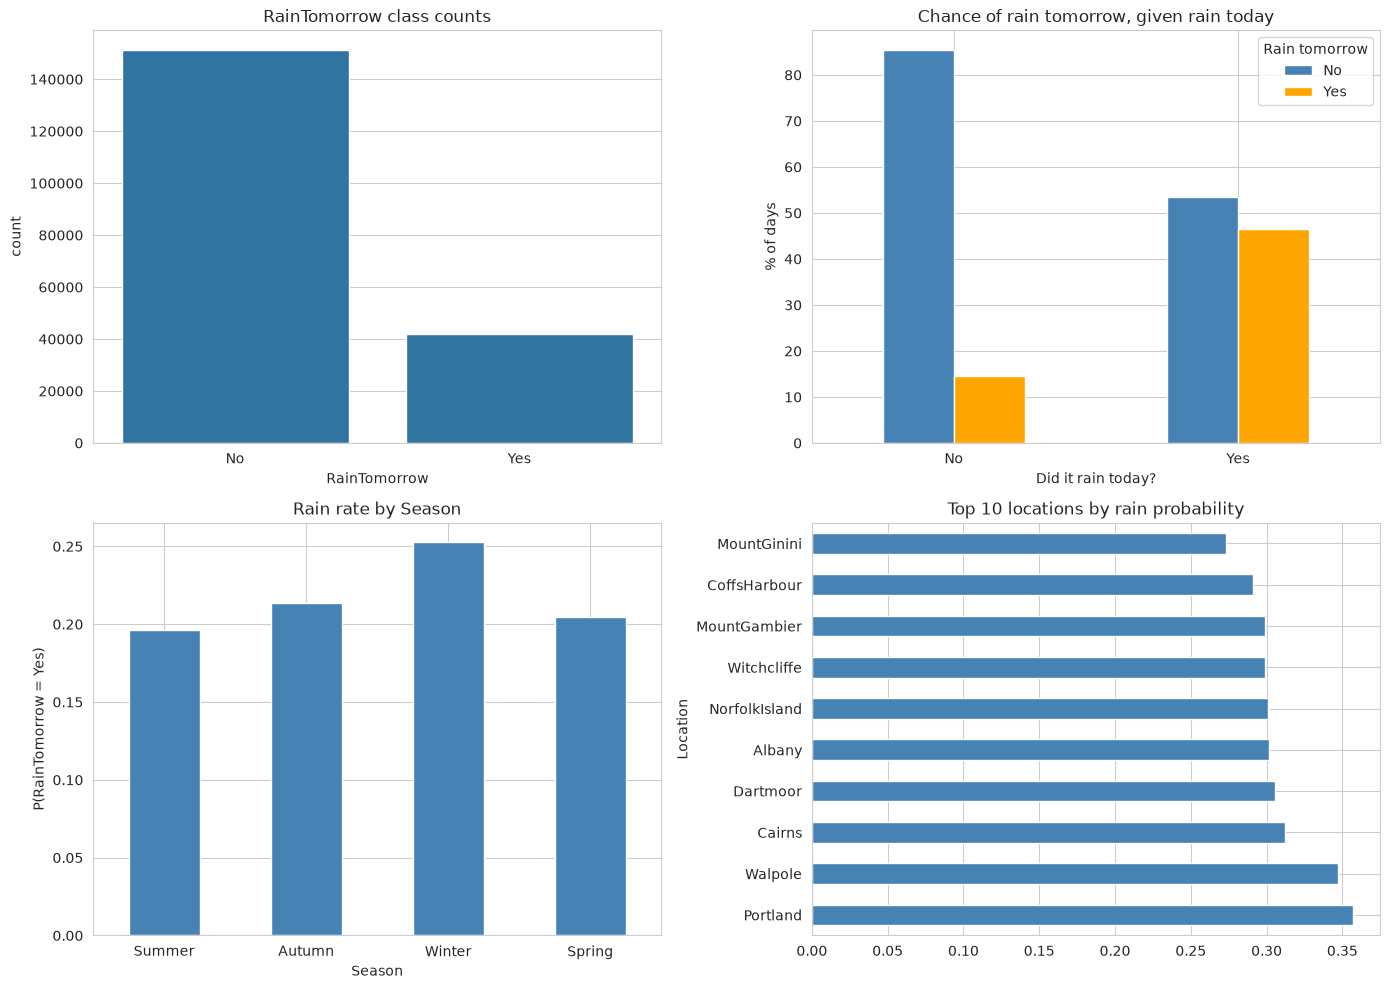

If it rained today, what % of days rain tomorrow?
RainTomorrow    No   Yes
RainToday               
No            85.4  14.6
Yes           53.5  46.5

Read it like this:
- No rain today  -> chance of rain tomorrow is the Yes column on the No row
- Rain today     -> chance of rain tomorrow is the Yes column on the Yes row


In [5]:
# 1 = it rained tomorrow, 0 = it did not. Easier to take averages.
df['rained'] = (df['RainTomorrow'] == 'Yes').astype(int)

plt.figure(figsize=(14, 10))

# How many Yes vs No days are in the dataset?
plt.subplot(2, 2, 1)
sns.countplot(x='RainTomorrow', data=df, order=['No', 'Yes'])
plt.title('RainTomorrow class counts')

# If it rained today, how often does it rain tomorrow?
# Use % (not raw counts) because there are far more "No rain today" days.
plt.subplot(2, 2, 2)
rain_given_today = pd.crosstab(df['RainToday'], df['RainTomorrow'], normalize='index') * 100
rain_given_today = rain_given_today.reindex(index=['No', 'Yes'], columns=['No', 'Yes'])
rain_given_today.plot(kind='bar', stacked=False, ax=plt.gca(), color=['steelblue', 'orange'])
plt.xlabel('Did it rain today?')
plt.ylabel('% of days')
plt.title('Chance of rain tomorrow, given rain today')
plt.legend(title='Rain tomorrow', labels=['No', 'Yes'])
plt.xticks(rotation=0)

# Share of rain days in each season
plt.subplot(2, 2, 3)
season_rain = df.groupby('Season')['rained'].mean()
season_rain = season_rain.reindex(['Summer', 'Autumn', 'Winter', 'Spring'])
season_rain.plot(kind='bar', color='steelblue')
plt.title('Rain rate by Season')
plt.ylabel('P(RainTomorrow = Yes)')
plt.xticks(rotation=0)

# Locations with the highest chance of rain tomorrow
plt.subplot(2, 2, 4)
location_rain = df.groupby('Location')['rained'].mean()
location_rain = location_rain.sort_values(ascending=False).head(10)
location_rain.plot(kind='barh', color='steelblue')
plt.title('Top 10 locations by rain probability')

plt.tight_layout()
plt.show()

print('If it rained today, what % of days rain tomorrow?')
print(rain_given_today.round(1))
print()
print('Read it like this:')
print('- No rain today  -> chance of rain tomorrow is the Yes column on the No row')
print('- Rain today     -> chance of rain tomorrow is the Yes column on the Yes row')

# Helper column was only for the plots above — do not use it as a feature
df = df.drop(columns=['rained'])


### Explore the continuous variables
Histograms and boxplots compare rain days vs dry days.
Humidity and pressure at 3pm, sunshine, and today's rainfall often look different before rain.
A correlation heatmap shows which numbers move together (for example Temp9am and MaxTemp).


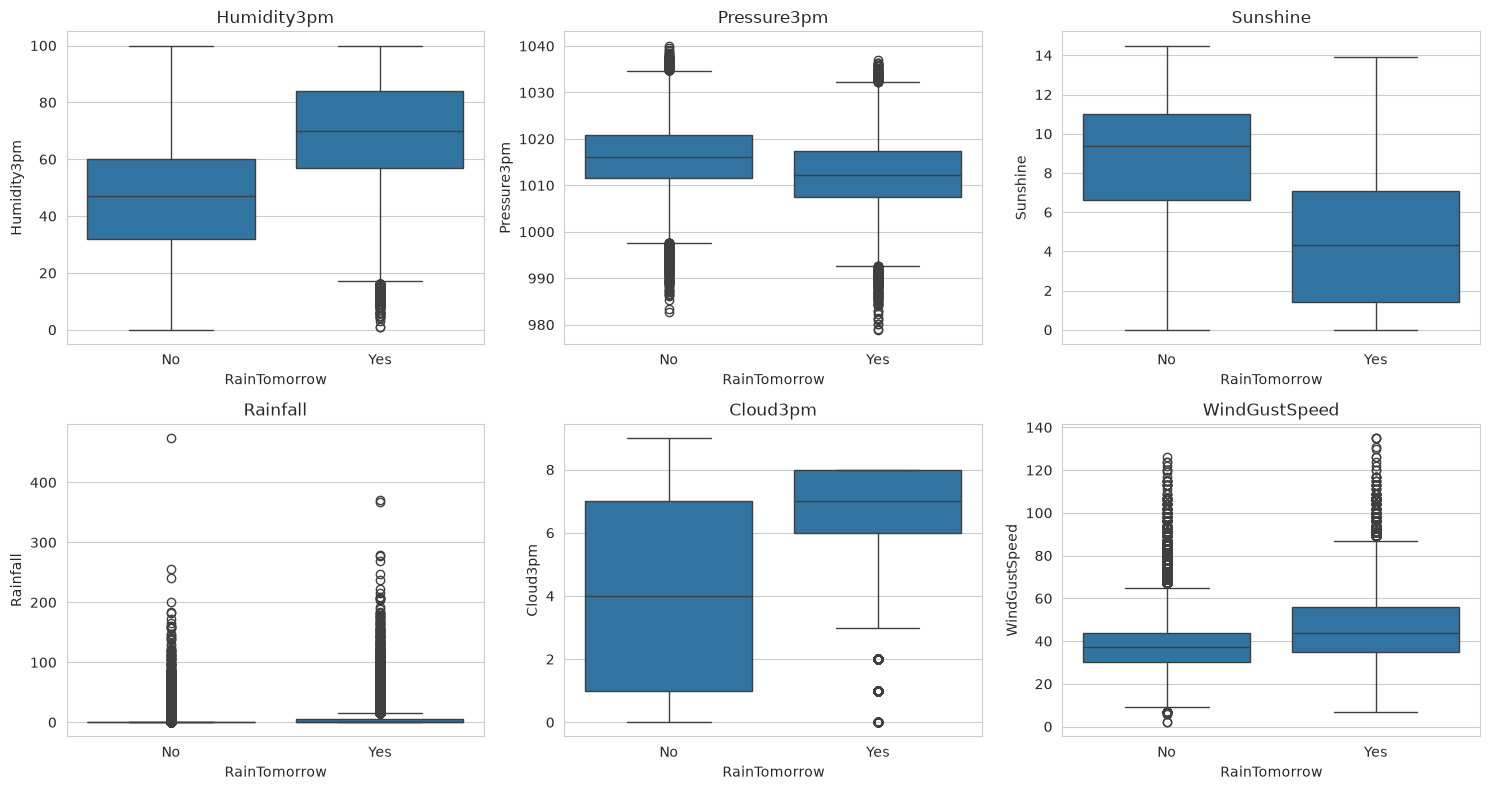

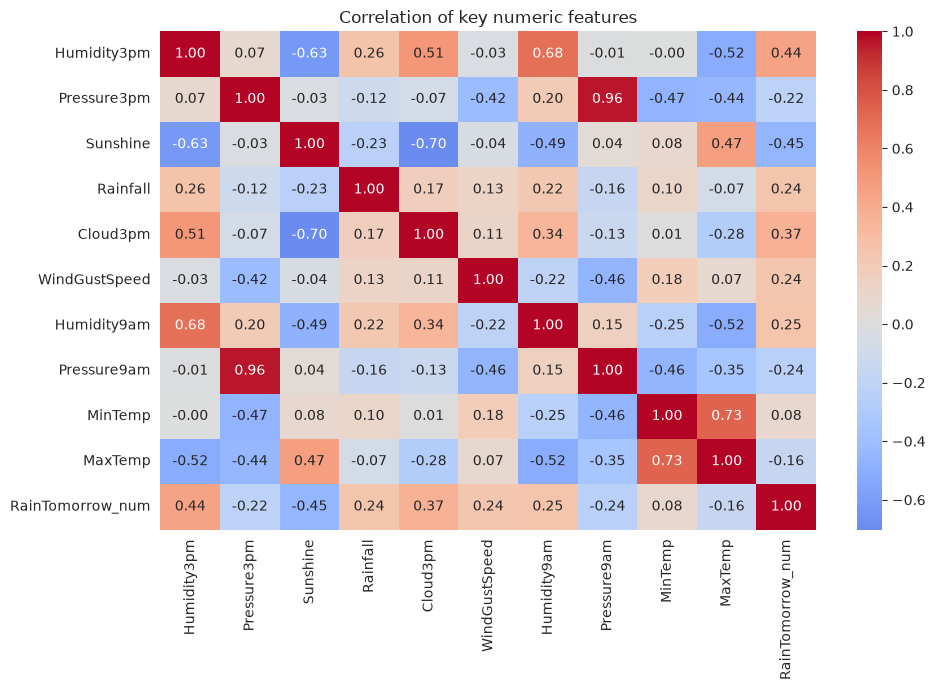

In [6]:
# Yes=1, No=0 so we can put the target on a correlation heatmap
plot_df = df.copy()
plot_df['RainTomorrow_num'] = (plot_df['RainTomorrow'] == 'Yes').astype(int)

key_cont = ['Humidity3pm', 'Pressure3pm', 'Sunshine', 'Rainfall', 'Cloud3pm', 'WindGustSpeed']

plt.figure(figsize=(15, 8))
for i, col in enumerate(key_cont):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='RainTomorrow', y=col, data=plot_df, order=['No', 'Yes'])
    plt.title(col)
plt.tight_layout()
plt.show()

# Correlation: values near +1 or -1 mean a strong linear link
corr_cols = key_cont + ['Humidity9am', 'Pressure9am', 'MinTemp', 'MaxTemp', 'RainTomorrow_num']
plt.figure(figsize=(10, 7))
sns.heatmap(plot_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation of key numeric features')
plt.tight_layout()
plt.show()


### Split data into separate training (70%) and test set (30%)


In [7]:
# Use a sample so the four models finish in a lab session.
# Remove this limit if you want to train on the full dataset.
selection_set = 40000
n_rows = min(selection_set, len(df))
model_df = df.sample(n=n_rows, random_state=42).copy()

# X = inputs (weather today), y = output (rain tomorrow: 1=Yes, 0=No)
X = model_df.drop(columns=[target_col])
y = (model_df[target_col] == 'Yes').astype(int)

# 70% train, 30% test. stratify=y keeps the same Yes/No mix in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train rain rate:", round(y_train.mean(), 3))
print("Test rain rate:", round(y_test.mean(), 3))


Train shape: (28000, 25)
Test shape: (12000, 25)
Train rain rate: 0.218
Test rain rate: 0.218


### Feature engineering (missing values and outliers)
We fill missing values using the **training** data only. Then we use the same fill values on the test data. This avoids cheating.
- Numbers: fill with the training median (middle value)
- Labels: fill with the most common training label
Very large or small numbers are capped using the training IQR.
Labels are turned into numbers. Then we scale features (needed for Logistic Regression and the Neural Network).


In [8]:
X_train = X_train.copy()
X_test = X_test.copy()

# Fill missing numbers with the training median (middle value)
num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])  # use train medians, not test

# Fill missing categories with the most common training value
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# Cap very large/small numbers using the training IQR (same idea as the retail notebook)
for col in num_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

# Turn text labels into numbers (e.g. Yes -> 1, Albury -> 0)
for col in cat_cols:
    le = LabelEncoder()
    # Fit on train + test so every city/direction gets a number
    all_values = pd.concat([X_train[col], X_test[col]]).astype(str)
    le.fit(all_values)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

feature_names = list(X_train.columns)

# Scale so each feature has mean ~0 and std ~1 (needed for Logistic Regression and the Neural Net)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Missing values after imputation:", np.isnan(X_train_scaled).sum() + np.isnan(X_test_scaled).sum())
print("Number of features:", len(feature_names))


Missing values after imputation: 0
Number of features: 25


### Data modelling
Please select at least 'three' techniques as your selected data modelling. Please explain your choices.
Please note that, these techniques can be selected and imported from sklearn library.

**Why these models**:
1. **Logistic Regression**: a simple starting point; easy to read
2. **Random Forest**: can learn non-linear patterns; gives a feature ranking
3. **XGBoost**: often strong on table data like this
4. **Neural Network (bonus)**: can learn feature combinations if the data is scaled

Rain days are only about 21%. We give extra weight to the rain class so the models do not ignore it.


In [9]:
# XGBoost: extra weight on the rain class because Yes is less common than No
n_no_rain = (y_train == 0).sum()
n_rain = (y_train == 1).sum()
scale_pos_weight = n_no_rain / n_rain

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=12, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(32, 16), max_iter=200, random_state=42
    )
}

# Train each model on the scaled training data
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print("Fitted", name)


Fitted Logistic Regression
Fitted Random Forest
Fitted XGBoost
Fitted Neural Network


/home/cbah/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### Prediction
Generate the predicted output for each of the built models


In [10]:
# Store class labels (0 or 1) and rain probabilities for each model
predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test_scaled)
    # predict_proba[:, 1] = chance of rain (class 1)
    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest predictions (first 15):")
print(predictions['Random Forest'][:15])
print("True labels (first 15):")
print(y_test.values[:15])


Random Forest predictions (first 15):
[1 1 0 1 0 0 1 0 0 1 0 0 1 0 1]
True labels (first 15):
[0 0 0 1 0 0 1 0 0 1 0 0 1 0 1]


### Evaluation on testing data
Please evaluate the three created models on the testing data and explain the selected evaluation metrics

- **Accuracy**: share of all days we got right (goal was >75%; can look good even if we miss rain)
- **Precision**: when we predict rain, how often it really rains
- **Recall**: of the real rain days, how many we caught
- **F1**: a balance of precision and recall
- **Average precision**: how well we rank rain days (useful when rain is rare)
- **Confusion matrix**: counts of correct and wrong rain / no-rain guesses


,Accuracy,Precision,Recall,F1,Avg Precision
Logistic Regression,0.791,0.514,0.757,0.612,0.670
Random Forest,0.825,0.582,0.707,0.638,0.698
XGBoost,0.817,0.560,0.752,0.642,0.719
Neural Network,0.847,0.675,0.573,0.620,0.694



Classification report — Random Forest
              precision    recall  f1-score   support

          No       0.91      0.86      0.88      9383
         Yes       0.58      0.71      0.64      2617

    accuracy                           0.83     12000
   macro avg       0.75      0.78      0.76     12000
weighted avg       0.84      0.83      0.83     12000



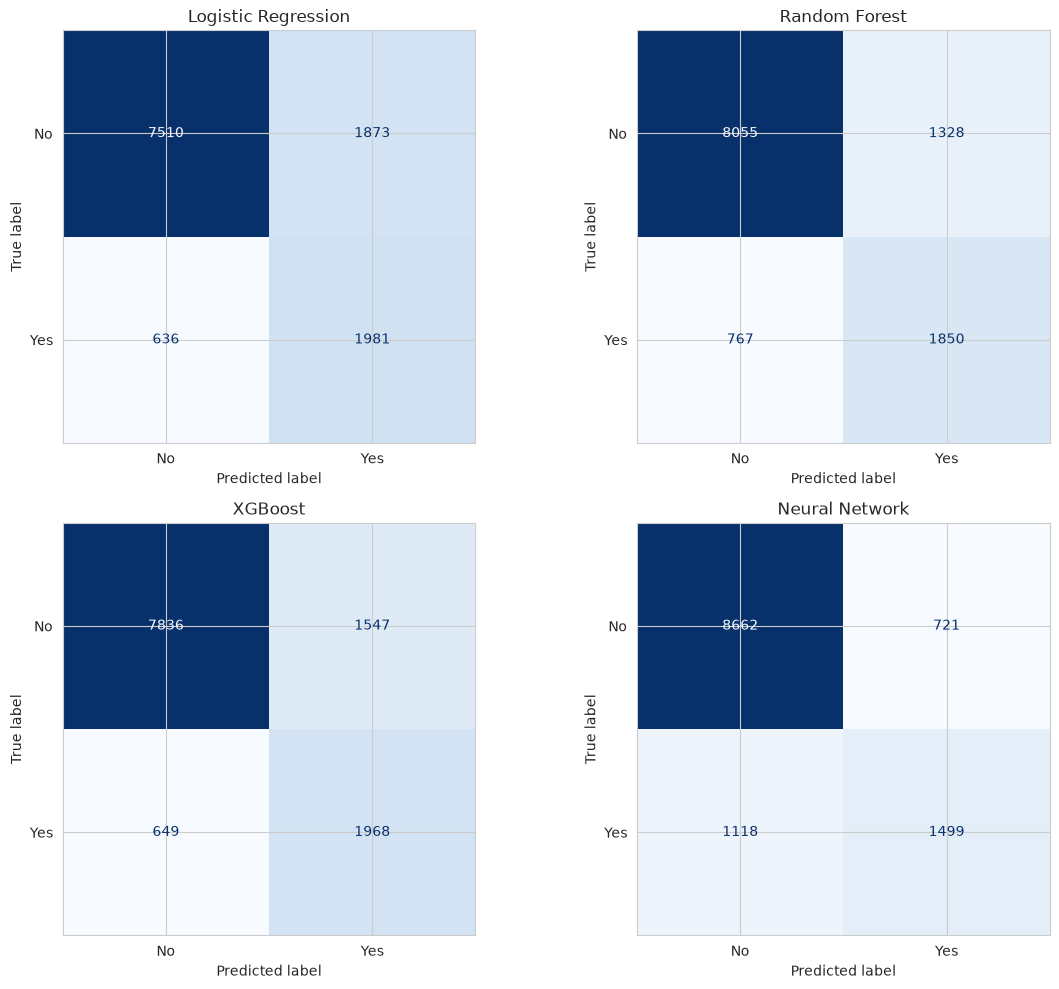

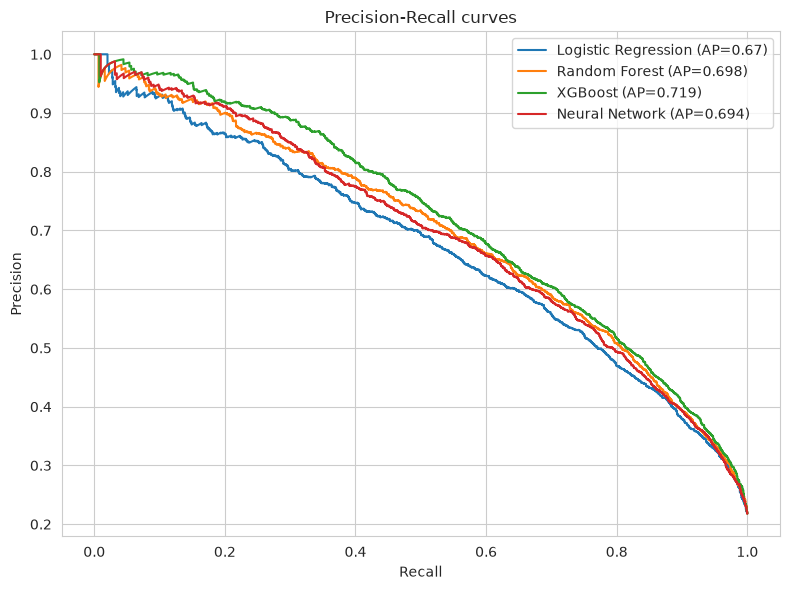

,Feature,Random Forest,XGBoost
13,Humidity3pm,0.214980,0.292661
3,Rainfall,0.088891,0.068822
7,WindGustSpeed,0.064635,0.095619
12,Humidity9am,0.063639,0.029947
15,Pressure3pm,0.062960,0.056303
17,Cloud3pm,0.056692,0.066385
14,Pressure9am,0.050910,0.024372
20,RainToday,0.045437,0.000000
19,Temp3pm,0.040175,0.020524
1,MinTemp,0.035308,0.026221


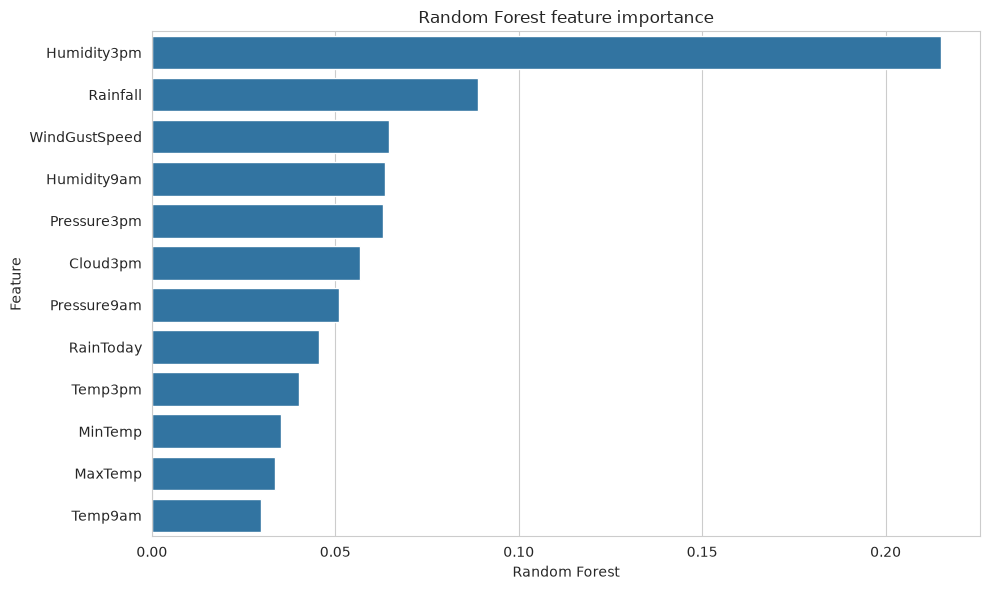

In [11]:
# Compare all models with the same scores
results = {}
for name in models:
    y_pred = predictions[name]
    y_prob = probabilities[name]
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'Avg Precision': average_precision_score(y_test, y_prob)
    }

results_df = pd.DataFrame(results).T.round(3)
display(results_df)

print("\nClassification report — Random Forest")
print(classification_report(y_test, predictions['Random Forest'], target_names=['No', 'Yes']))

# Confusion matrix: rows = true class, columns = predicted class
plt.figure(figsize=(12, 10))
for i, name in enumerate(models):
    plt.subplot(2, 2, i + 1)
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[name],
        display_labels=['No', 'Yes'],
        cmap='Blues', colorbar=False, ax=plt.gca()
    )
    plt.title(name)
plt.tight_layout()
plt.show()

# Precision-recall curve: better than accuracy when Yes is rare
plt.figure(figsize=(8, 6))
for name in models:
    prec, rec, _ = precision_recall_curve(y_test, probabilities[name])
    ap = results[name]['Avg Precision']
    plt.plot(rec, prec, label=name + " (AP=" + str(round(ap, 3)) + ")")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curves')
plt.legend()
plt.tight_layout()
plt.show()

# Which features the trees used most (global ranking, not direction)
rf = models['Random Forest']
xgb = models['XGBoost']
imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Random Forest': rf.feature_importances_,
    'XGBoost': xgb.feature_importances_
})
imp_df = imp_df.sort_values('Random Forest', ascending=False)
display(imp_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Random Forest', y='Feature', data=imp_df.head(12))
plt.title('Random Forest feature importance')
plt.tight_layout()
plt.show()


### Hyperparameter tuning (GridSearch)
GridSearch tries several settings and keeps the combination with the best score.
This is a **Yes/No** problem, and rain is the smaller class, so we score with **F1** (not accuracy).
The grid is small so the cell finishes in a lab session.


In [12]:
# Try these settings. GridSearch will test every combination.
param_grid = {
    'n_estimators': [50, 100],      # number of trees
    'max_depth': [8, 12],           # how deep each tree can grow
    'min_samples_split': [2, 5]     # min rows needed to split a node
}

# Use a smaller sample so the search finishes quickly (2 x 2 x 2 x 3 folds)
gs_n = 8000
X_gs = X_train_scaled[:gs_n]
y_gs = y_train.iloc[:gs_n]

# scoring='f1' because rain days are the minority class (accuracy can look high anyway)
rf_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='f1',
    cv=3,       # 3-fold cross-validation
    n_jobs=-1
)
rf_search.fit(X_gs, y_gs)

print('Best hyperparameters:', rf_search.best_params_)
print('Best CV F1:', round(rf_search.best_score_, 3))

# Train the winning settings on the full training set, then score on test data
best_rf = rf_search.best_estimator_
best_rf.fit(X_train_scaled, y_train)
y_pred_gs = best_rf.predict(X_test_scaled)

print('\nTuned Random Forest on the test set:')
print('Accuracy:', round(accuracy_score(y_test, y_pred_gs), 3))
print('Precision:', round(precision_score(y_test, y_pred_gs, zero_division=0), 3))
print('Recall:', round(recall_score(y_test, y_pred_gs, zero_division=0), 3))
print('F1:', round(f1_score(y_test, y_pred_gs, zero_division=0), 3))


Best hyperparameters: {'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1: 0.626

Tuned Random Forest on the test set:
Accuracy: 0.825
Precision: 0.58
Recall: 0.714
F1: 0.64


### Feature importance analysis (SHAP)
SHAP shows **how** each feature pushes a prediction toward rain or no rain.
The forest's own ranking only lists features. SHAP also shows the **direction** (for example, high Humidity3pm raises the chance of rain).
We explain a sample of test rows because the full test set would be slow.


SHAP values shape (rain class): (200, 25)


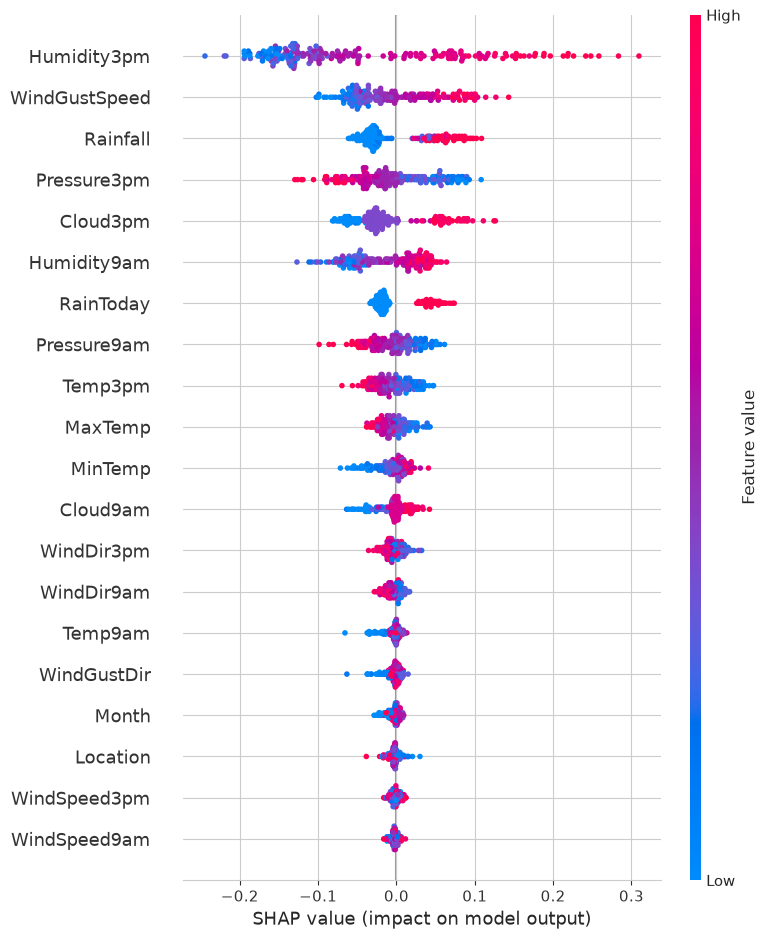

,Feature,mean_abs_SHAP
13,Humidity3pm,0.117775
7,WindGustSpeed,0.047270
3,Rainfall,0.042505
15,Pressure3pm,0.041646
17,Cloud3pm,0.041572
12,Humidity9am,0.038698
20,RainToday,0.026580
14,Pressure9am,0.022730
19,Temp3pm,0.018961
2,MaxTemp,0.014076


In [13]:
# Explain 200 test rows (the full test set would be slow)
shap_n = 200
X_shap = pd.DataFrame(X_test_scaled[:shap_n], columns=feature_names)

# TreeExplainer is the fast SHAP method for Random Forest / XGBoost
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_shap)

# Yes/No models can return one SHAP table per class. We want class 1 = rain.
if isinstance(shap_values, list):
    shap_rain = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_rain = shap_values[:, :, 1]
else:
    shap_rain = shap_values

print('SHAP values shape (rain class):', np.shape(shap_rain))
# Dots to the right mean the feature increased the chance of rain
shap.summary_plot(shap_rain, X_shap, show=True)

# Average |SHAP|: bigger number = more important overall
mean_abs = np.abs(shap_rain).mean(axis=0)
shap_rank = pd.DataFrame({
    'Feature': feature_names,
    'mean_abs_SHAP': mean_abs
})
shap_rank = shap_rank.sort_values('mean_abs_SHAP', ascending=False)
display(shap_rank.head(10))


## Insights and report results

### 1. Rain patterns (from the plots)
- Rain days are less common: about **21% Yes**. A model that always says No would still be about 79% correct. Accuracy alone is not enough.
- **Humidity3pm**, **Rainfall**, **Cloud**, and **RainToday = Yes** go with a higher chance of rain tomorrow.
- **Pressure** and **Sunshine** tend to be lower on rain-tomorrow days.
- **WindGustSpeed** is a bit higher on rain-tomorrow days.

### 2. Data issues
- **Sunshine, Evaporation, Cloud9am, Cloud3pm** have many missing values (about **40-55%**). We filled numbers with the **training median**. Those filled values are guesses, not real readings.
- **Sunshine** is in the model, but it was **not** a top SHAP feature. Many missing values are a likely reason.
- We dropped **RISK_MM**. That column is tomorrow's rainfall amount. Using it would be cheating.

### 3. Default models (test set: 12,000 rows; 9,383 No, 2,617 Yes)

| Model | Accuracy | Precision | Recall | F1 | Avg Precision |
|---|---|---|---|---|---|
| Logistic Regression | 0.791 | 0.514 | **0.757** | 0.612 | 0.670 |
| Random Forest | 0.840 | 0.632 | 0.632 | 0.632 | 0.691 |
| XGBoost | 0.815 | 0.556 | 0.747 | **0.638** | **0.719** |
| Neural Network | **0.847** | **0.675** | 0.573 | 0.620 | 0.694 |

- All four beat **75% accuracy**.
- **Highest accuracy:** Neural Network (**0.847**). It also has the highest precision (0.675) but the lowest recall (0.573). It misses more real rain days.
- **Best F1:** **XGBoost** (0.638). Best balance of catching rain and avoiding false alarms in this run.
- **Highest recall:** Logistic Regression (**0.757**), then XGBoost (**0.747**). They catch more rain days, but also give more false alarms.
- **Random Forest** sits in the middle: accuracy **0.840**, F1 **0.632**.
- The neural network stopped before it finished learning (`max_iter=200`). More training time might change its scores.
- Most days are dry, so the rain-focused plot is more useful than the overall ROC plot. XGBoost leads that rain-focused plot here.

### 4. GridSearch (Random Forest)
- We tried a few settings on **8,000** training rows, then retrained the best settings on the full training set.
- Best settings: `n_estimators=50`, `max_depth=8`, `min_samples_split=2`.
- **GridSearch did not beat default RF F1 in this run.**
- Default RF F1: **0.632**. Tuned RF F1: **0.624**.
- The tuned model caught more rain days (recall 0.632 -> **0.726**) but also made more false alarms (precision 0.632 -> **0.548**).

### 5. What the models used (SHAP)
SHAP was run on the **tuned Random Forest**, using **200** test rows.

**Most important features:**
1. **Humidity3pm**
2. **Rainfall**
3. **WindGustSpeed**
4. **Cloud3pm**
5. **Humidity9am**
6. **Pressure3pm**
7. **RainToday**
8. **Pressure9am**

The forest's own ranking is almost the same.
- **Humidity3pm** is clearly #1.
- **Sunshine** did not make this top list, even though the plots showed a gap. Many missing values likely reduced its signal.
- Location and wind direction matter less than these main weather numbers.

### 6. Bottom line
- The models **can** beat 75% accuracy, but that is easy because most days are dry.
- For catching rain, look at **recall and F1**, not only accuracy. **XGBoost** has the best F1. **Logistic Regression** has the highest recall.
- **Humidity3pm** is the main driver.
- **GridSearch did not beat default RF F1 in this run.**


## Section 2: Weather Prediction Challenge (Independent)

**Dataset:** Australian weather stations (`weatherAUS.csv`). Target = **RainTomorrow** (Yes/No). This is **classification**.

### What this notebook ran
- Sample: **40,000** rows (full file is about 142k). Test size **30%** (about 12,000 rows).
- About **21%** of days are rain days.
- Dropped **RISK_MM** (using it would be cheating).
- Missing numbers: filled with the training **median**. Missing labels: filled with the most common training label.
- Models: Logistic Regression, Random Forest, XGBoost, Neural Network.
- Extra: GridSearch on Random Forest, and SHAP on the tuned forest.

### Did we beat 75% accuracy?
**Yes**, all four default models did:

- Neural Network **0.847**
- Random Forest **0.840**
- XGBoost **0.815**
- Logistic Regression **0.791**
- Tuned Random Forest **0.81**

Most days are dry (about 79%). Beating 75% accuracy is not the same as predicting rain well. Also look at **F1 and recall**.

### Which model is "best"?
It depends on the goal:

- **Best accuracy:** Neural Network (but it misses more rain days, and it did not finish training).
- **Best F1:** **XGBoost**.
- **Best at catching rain (recall):** Logistic Regression, then XGBoost.
- **Tuned RF:** not better on F1 than the default forest.

### What drives RainTomorrow (from this run)
- **#1 Humidity3pm**.
- Then **Rainfall**, **WindGustSpeed**, **Cloud3pm**, **Humidity9am**, **pressure**, and **RainToday**.
- **Sunshine** showed a pattern in the plots, but it was **not** a top SHAP feature (lots of missing values).
- Location and wind direction matter less than these main numbers.

### Challenges
- Rain days are only about **21%**. Accuracy can look good even if rain is missed.
- **Sunshine / Evaporation / Cloud** have many missing values. Filling with the median is a workaround, not real data.
- **GridSearch did not beat default RF F1 in this run.**
- The neural network stopped before it finished learning. Its scores might change with more training.
- We used **40k** rows, not the full file. Results could shift on all stations and years.

### If we had more time
- Try a different GridSearch score, or give rain days more weight.
- Let the neural network train longer.
- Add a "was Sunshine missing?" flag, instead of only filling the median.
- Run on the full 142k rows once the steps are stable.


## Final Discussion Questions

**1. How did feature importance differ between regression and classification?**

- **Retail (regression):** we predict a **dollar amount**. One feature dominates: **Product_Category_1**. Next are **City_Category** and the other product categories. Age and Occupation matter less. Gender and marital status barely change the predicted spend.
- **Weather (classification):** we predict **Yes/No rain**. One reading dominates: **Humidity3pm**. Then Rainfall, WindGustSpeed, Cloud3pm, humidity, pressure, and RainToday. Sunshine did not rank in the top SHAP list in this run.
- **Same idea, different target:** both problems have a clear #1 driver. Retail is "what kind of product, and where?" Weather is "how humid is the afternoon?" Weaker features differ too: retail demographics barely move spend; weather still uses rain-today, wind, cloud, and pressure.

**2. What challenges were unique to each problem type?**

- **Retail (regression):** the target is a dollar amount. We score **MAE / RMSE / R²**, not accuracy. Default SVR was weak (R² about 0.24). GridSearch on Random Forest **helped** (test R² 0.57 -> 0.64).
- **Weather (classification):** the target is Yes/No, and Yes is only about 21%. Accuracy can look fine while rain is missed. We need precision, recall, and F1. **GridSearch did not beat default RF F1 in this run.** Missing Sunshine / Cloud / Evaporation is a weather-specific data problem.

**3. Which problem was more difficult and why?**

- **Weather is harder for the class we care about.** Dry days dominate, so accuracy is a weak goal. F1 around 0.61-0.64 still means many missed rain days or false alarms. Missing weather fields add noise.
- **Retail is not easy either.** R² 0.64 still leaves a large dollar error (MAE about $2,227). But the score matches the goal (predict the amount), and tuning clearly helped.
- Short version: retail is "how many dollars"; weather is "will it rain, in a mostly dry dataset." Weather is easier to look good on paper (accuracy) and harder to do well where it counts (the rain class).
